# 03. PPO-Lagrangian 정책 학습

`ppo_lagrangian.py` 의 `train()` 으로 정책을 학습합니다. 원 논문과의 차이:

| 항목 | 원 논문 | 이 노트북 |
|---|---|---|
| 시간 간격 | 일 | 시간 |
| 라그랑주 승수 | 1개 (통합 제약 비용) | **2개: flood, drought** — 임계값과 초기 승수를 다르게 두어 홍수 > 가뭄 우선순위를 표현 |
| 발전 | 보상의 주 항 + 보증출력 제약 | 보상의 작은 항(0.05), **제약 없음** |
| 정책 조건 | 없음 | **운영자 목표 위치**를 입력으로 받아 하나의 모델이 상한/중간/하한 운영을 모두 수행 |
| 에피소드 | 4년 | 30일(720h), 시작일·초기수위·습윤도 무작위 |

### 쌍대 업데이트

$$\lambda_k \leftarrow \mathrm{clip}\big(\lambda_k + \eta_k\,(\bar c_k - d_k),\ 0,\ \lambda_{max}\big),\quad k\in\{flood, drought\}$$

기본값: 임계값 `d = (0.005, 0.02)`, 초기 승수 `(2, 1)`, 학습률 `(2.0, 1.0)`, 상한 10. 홍수 쪽이 더 엄격합니다.

### 학습 시작점

무작위 정책은 하루 만에 저수지를 비우므로, 먼저 규칙(`TargetTrackingRule`)을 **행동복제(BC)** 한 뒤 PPO 로 개선합니다. 에피소드 초기수위는 밴드 **바깥**(하한 −1 m ~ 상한 +2.5 m)까지 샘플링하여 홍수 후 복귀 운영도 학습합니다.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
sys.path.insert(0, ".")
import hourly_reservoir as hr, ppo_lagrangian as pl
plt.rcParams["figure.figsize"] = (12, 3.4)
print("device:", pl.DEVICE)

device: cuda


## 1. 학습

`N_ITERS=200` 은 GPU 에서 약 5분 걸립니다. 더 좋은 정책을 원하면 늘리십시오. 결과는 `models/policy.pt` 에 저장되어 노트북 04, 05 에서 사용됩니다.

In [2]:
N_ITERS = 200
model, hist = pl.train(n_envs=8, horizon=24 * 30, n_iters=N_ITERS, log_every=10, seed=0, lr=2e-4,
                       thresholds=(0.005, 0.02), initial_penalty=(2.0, 1.0), lag_lr=(2.0, 1.0), dual_clip=10.0,
                       target_choices=(0.2, 0.35, 0.5, 0.65, 0.8), wetness_range=(0.7, 1.5),
                       init_spread=(-1.0, 2.5),          # start some episodes outside the band so the policy learns to recover
                       save_path="models/policy.pt")
hist.tail(3)

  BC epoch   0 | nll 2.501 | samples 11520


  BC epoch  10 | nll 1.217 | samples 11520


  BC epoch  20 | nll 0.949 | samples 11520


  BC epoch  29 | nll 0.814 | samples 11520


iter   0 | ret   -98.67 | flood 0.0030 | drought 0.0037 | band  97.1% | lam 2.00/0.98 | 2s


...

iter 170 | ret   -66.01 | flood 0.0014 | drought 0.0019 | band  97.5% | lam 1.15/0.00 | 265s


iter 180 | ret  -125.69 | flood 0.0000 | drought 0.0035 | band  97.7% | lam 1.14/0.00 | 281s


iter 190 | ret  -197.15 | flood 0.0036 | drought 0.0102 | band  94.0% | lam 1.11/0.00 | 296s


iter 199 | ret  -151.90 | flood 0.0003 | drought 0.0028 | band  98.8% | lam 1.09/0.00 | 309s


,iter,ret,flood_cost,drought_cost,band_pct,lam_flood,lam_drought,sec
197,197,-199.369905,0.003538,0.009852,93.506944,1.101264,0.0,306.306748
198,198,-116.811087,0.002733,0.002263,97.812500,1.096731,0.0,307.824363
199,199,-151.902705,0.000287,0.002784,98.836806,1.087305,0.0,309.347426


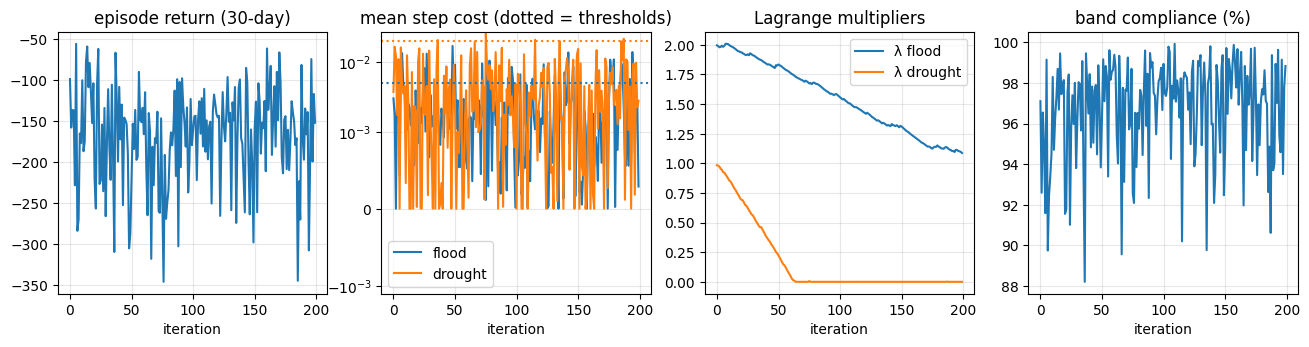

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
axes[0].plot(hist.iter, hist.ret); axes[0].set_title("episode return (30-day)")
axes[1].plot(hist.iter, hist.flood_cost, label="flood"); axes[1].plot(hist.iter, hist.drought_cost, label="drought"); axes[1].axhline(0.005, c="tab:blue", ls=":"); axes[1].axhline(0.02, c="tab:orange", ls=":"); axes[1].set_yscale("symlog", linthresh=1e-3); axes[1].legend(); axes[1].set_title("mean step cost (dotted = thresholds)")
axes[2].plot(hist.iter, hist.lam_flood, label="λ flood"); axes[2].plot(hist.iter, hist.lam_drought, label="λ drought"); axes[2].legend(); axes[2].set_title("Lagrange multipliers")
axes[3].plot(hist.iter, hist.band_pct); axes[3].set_title("band compliance (%)")
for a in axes: a.grid(alpha=.3); a.set_xlabel("iteration")

## 2. 규칙 베이스라인과 비교 (1년, 운영자 선호 3가지)

같은 유입량·예측 시나리오에서 정책과 규칙을 비교합니다. 표의 행 순서가 우선순위입니다.

In [4]:
env = hr.HourlyReservoirEnv()
agent = pl.PolicyAgent(model, greedy=True)
rows = {}
for tp in (0.2, 0.5, 0.8):
    for name, pol in (("policy", agent), ("rule", hr.TargetTrackingRule(env))):
        log = hr.run_episode(env, pol, seed=3, start_doy=0, horizon_hours=8760, target_position=tp)
        rows[f"{name}_tp{tp}"] = hr.summarize(log)
cmp = pd.DataFrame(rows)
cmp.loc[["flood_hours_above_upper", "hours_above_design_flood", "downstream_over_capacity_hours", "downstream_max_flow",
         "drought_hours_below_lower", "env_flow_violation_hours", "band_compliance_pct", "mean_abs_target_dev_m",
         "ramp_over_limit_hours", "mask_relaxed_hours", "energy_GWh"]].round(2)

,policy_tp0.2,rule_tp0.2,policy_tp0.5,rule_tp0.5,policy_tp0.8,rule_tp0.8
flood_hours_above_upper,16.00,33.00,16.00,38.00,22.00,91.00
hours_above_design_flood,0.00,0.00,0.00,0.00,0.00,0.00
downstream_over_capacity_hours,1.00,1.00,1.00,1.00,1.00,1.00
downstream_max_flow,2623.82,2589.33,2635.53,2638.51,2638.23,2645.79
drought_hours_below_lower,50.00,56.00,20.00,28.00,9.00,6.00
env_flow_violation_hours,0.00,0.00,0.00,0.00,0.00,0.00
band_compliance_pct,99.25,98.98,99.59,99.25,99.65,98.89
mean_abs_target_dev_m,0.37,0.10,0.44,0.18,0.66,0.53
ramp_over_limit_hours,1.00,2.00,0.00,3.00,1.00,3.00
mask_relaxed_hours,16.00,19.00,16.00,17.00,20.00,20.00


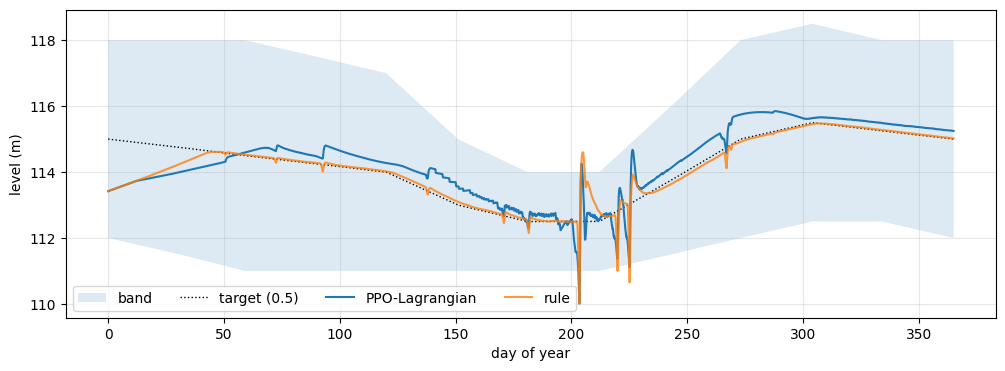

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
log_p = hr.run_episode(env, agent, seed=3, start_doy=0, horizon_hours=8760, target_position=0.5)
log_r = hr.run_episode(env, hr.TargetTrackingRule(env), seed=3, start_doy=0, horizon_hours=8760, target_position=0.5)
ax.fill_between(log_p.doy, log_p.lower, log_p.upper, alpha=.15, label="band"); ax.plot(log_p.doy, log_p.target, "k:", lw=1, label="target (0.5)")
ax.plot(log_p.doy, log_p.level, label="PPO-Lagrangian"); ax.plot(log_r.doy, log_r.level, label="rule", alpha=.8)
ax.set_xlabel("day of year"); ax.set_ylabel("level (m)"); ax.legend(ncol=4); ax.grid(alpha=.3)

## 정리

* 두 승수는 각 제약 그룹의 평균 비용이 임계값을 넘으면 커지고, 아래로 내려오면 줄어듭니다. 홍수 임계값이 더 작으므로 홍수 승수가 더 크게 유지됩니다.
* 정책은 `target_position` 을 입력으로 받아 학습했으므로 노트북 04 에서 운영자가 값을 바꿔 가며 권고안을 비교할 수 있습니다.
* 200 반복 기준으로 정책은 **우선순위가 높은 지표**(하류 계획홍수량 초과, 방류 변화율 위반, 가뭄 시간)에서 규칙보다 좋거나 같고, **우선순위가 낮은 지표**(상한 초과 시간, 목표수위 추종 정밀도)에서는 규칙보다 못할 수 있습니다. 규칙은 목표수위를 해석적으로 계산하므로 추종 정밀도에서 유리합니다.
* 실무 적용 전에는 `N_ITERS` 를 500 이상으로 늘리고, 시드 5개로 반복해 분산을 확인하십시오. 학습 곡선의 급격한 스파이크는 습윤도·시작일·초기수위가 무작위인 30일 에피소드 때문이며, 평가(greedy)에서는 나타나지 않습니다.